Selected features: ['age', 'Medu', 'Fedu', 'failures', 'higher', 'goout', 'G1', 'G2']
Feature scores: {'school': np.float64(0.7980416422082748), 'sex': np.float64(4.251814371189965), 'age': np.float64(10.535469672737323), 'address': np.float64(4.445163854236358), 'famsize': np.float64(2.6218323772433503), 'Pstatus': np.float64(1.3269268029204095), 'Medu': np.float64(19.44818367311801), 'Fedu': np.float64(9.351913081826945), 'Mjob': np.float64(4.138457966560859), 'Fjob': np.float64(0.7039801251223342), 'reason': np.float64(5.937207679024821), 'guardian': np.float64(1.9412491787414397), 'traveltime': np.float64(5.467880066286745), 'studytime': np.float64(3.796826493848806), 'failures': np.float64(58.67166578410455), 'schoolsup': np.float64(2.7121670878360487), 'famsup': np.float64(0.6035051787521534), 'paid': np.float64(4.131451064846012), 'activities': np.float64(0.10189216053998996), 'nursery': np.float64(1.0478711726566152), 'higher': np.float64(13.534903449348596), 'internet': np.flo

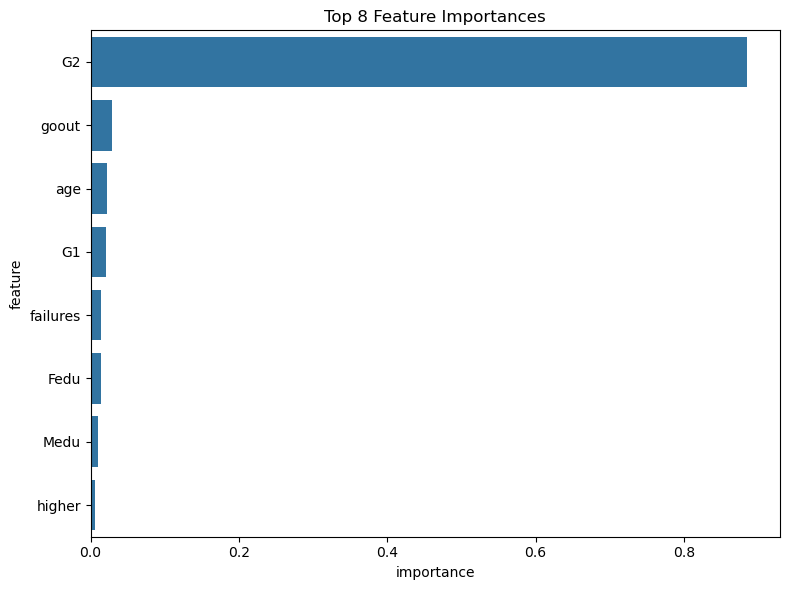

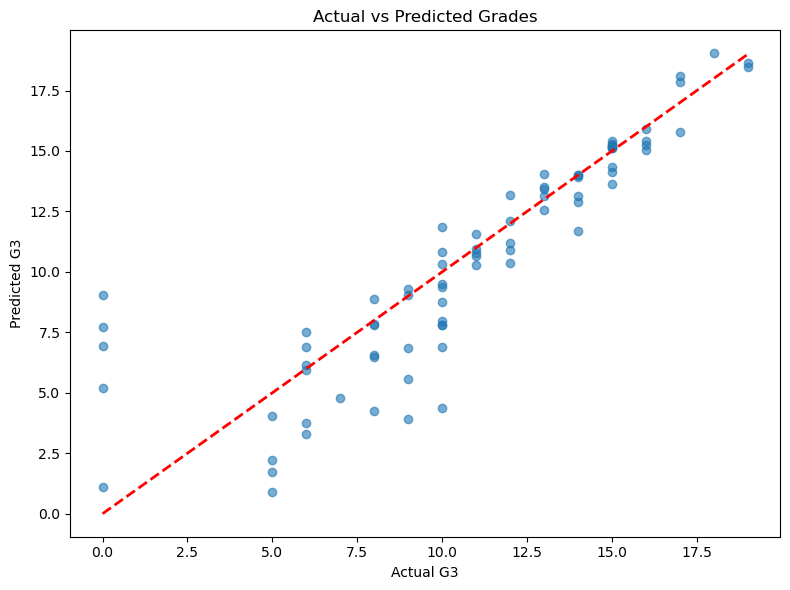

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('mat2.csv')

# Drop irrelevant column
df = df.drop('Unnamed: 0', axis=1)

# Target is G3 (FinalGrade)
target = 'G3'

# Identify categorical and numerical features
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['int64']).columns.drop(target).tolist()

# Encode categorical variables
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Features and target
X = df.drop(target, axis=1)
y = df[target]

# Feature selection: Select top 8 using f_regression (univariate)
selector = SelectKBest(score_func=f_regression, k=8)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()].tolist()

print("Selected features:", selected_features)
print("Feature scores:", dict(zip(X.columns, selector.scores_)))

X_sel = pd.DataFrame(X_selected, columns=selected_features, index=X.index)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest with light tuning
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
search = RandomizedSearchCV(rf, param_dist, n_iter=10, cv=5, random_state=42, n_jobs=-1)
search.fit(X_train_scaled, y_train)

model = search.best_estimator_
y_pred = model.predict(X_test_scaled)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Best params: {search.best_params_}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

# Most important feature
importances = model.feature_importances_
feat_imp = pd.DataFrame({'feature': selected_features, 'importance': importances}).sort_values('importance', ascending=False)
print("Feature importances:\n", feat_imp)
most_important = feat_imp.iloc[0]['feature']
print(f"Most important feature: {most_important}")

# Plot feature importance
plt.figure(figsize=(8, 6))
sns.barplot(data=feat_imp, x='importance', y='feature')
plt.title('Top 8 Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')

# Plot actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('Actual vs Predicted Grades')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300, bbox_inches='tight')

print("Plots saved: feature_importance.png, actual_vs_predicted.png")
